In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [42]:
df = pd.read_csv("synthetic_coffee_health_10000.csv")

In [43]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [44]:
df.tail

<bound method NDFrame.tail of          ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0         1   40    Male  Germany            3.5        328.1          7.5   
1         2   33    Male  Germany            1.0         94.1          6.2   
2         3   42    Male   Brazil            5.3        503.7          5.9   
3         4   53    Male  Germany            2.6        249.2          7.3   
4         5   32  Female    Spain            3.1        298.0          5.3   
...     ...  ...     ...      ...            ...          ...          ...   
9995   9996   50  Female    Japan            2.1        199.8          6.0   
9996   9997   18  Female       UK            3.4        319.2          5.8   
9997   9998   26    Male    China            1.6        153.4          7.1   
9998   9999   40  Female  Finland            3.4        327.1          7.0   
9999  10000   42  Female   Brazil            2.9        277.5          6.4   

     Sleep_Quality   BMI  Heart_R

In [45]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 10000
Columnas: 16


In [46]:
df.info

<bound method DataFrame.info of          ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0         1   40    Male  Germany            3.5        328.1          7.5   
1         2   33    Male  Germany            1.0         94.1          6.2   
2         3   42    Male   Brazil            5.3        503.7          5.9   
3         4   53    Male  Germany            2.6        249.2          7.3   
4         5   32  Female    Spain            3.1        298.0          5.3   
...     ...  ...     ...      ...            ...          ...          ...   
9995   9996   50  Female    Japan            2.1        199.8          6.0   
9996   9997   18  Female       UK            3.4        319.2          5.8   
9997   9998   26    Male    China            1.6        153.4          7.1   
9998   9999   40  Female  Finland            3.4        327.1          7.0   
9999  10000   42  Female   Brazil            2.9        277.5          6.4   

     Sleep_Quality   BMI  Heart

In [47]:
df.dtypes

ID                           int64
Age                          int64
Gender                         str
Country                        str
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality                  str
BMI                        float64
Heart_Rate                   int64
Stress_Level                   str
Physical_Activity_Hours    float64
Health_Issues                  str
Occupation                     str
Smoking                      int64
Alcohol_Consumption          int64
dtype: object

In [48]:
df.describe

<bound method NDFrame.describe of          ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0         1   40    Male  Germany            3.5        328.1          7.5   
1         2   33    Male  Germany            1.0         94.1          6.2   
2         3   42    Male   Brazil            5.3        503.7          5.9   
3         4   53    Male  Germany            2.6        249.2          7.3   
4         5   32  Female    Spain            3.1        298.0          5.3   
...     ...  ...     ...      ...            ...          ...          ...   
9995   9996   50  Female    Japan            2.1        199.8          6.0   
9996   9997   18  Female       UK            3.4        319.2          5.8   
9997   9998   26    Male    China            1.6        153.4          7.1   
9998   9999   40  Female  Finland            3.4        327.1          7.0   
9999  10000   42  Female   Brazil            2.9        277.5          6.4   

     Sleep_Quality   BMI  Hea

In [49]:
df.isnull().sum()

ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

In [50]:
(df.isnull().sum() / len(df)) * 100

ID                          0.00
Age                         0.00
Gender                      0.00
Country                     0.00
Coffee_Intake               0.00
Caffeine_mg                 0.00
Sleep_Hours                 0.00
Sleep_Quality               0.00
BMI                         0.00
Heart_Rate                  0.00
Stress_Level                0.00
Physical_Activity_Hours     0.00
Health_Issues              59.41
Occupation                  0.00
Smoking                     0.00
Alcohol_Consumption         0.00
dtype: float64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df = df.drop_duplicates()

print("Duplicados eliminados")

Duplicados eliminados


In [53]:
columnas_numericas = df.select_dtypes(include=np.number).columns
columnas_numericas

Index(['ID', 'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
       'Heart_Rate', 'Physical_Activity_Hours', 'Smoking',
       'Alcohol_Consumption'],
      dtype='str')

In [54]:
for columna in columnas_numericas:
    df[columna] = df[columna].fillna(df[columna].mean())

print("Valores numericos corregidos")


Valores numericos corregidos


In [55]:
columnas_categoricas = df.select_dtypes(include= "object").columns

columnas_categoricas

C:\Users\diego\AppData\Local\Temp\ipykernel_70568\327137532.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include= "object").columns


Index(['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues',
       'Occupation'],
      dtype='str')

In [56]:
for columna in columnas_categoricas:
    moda = df[columna].mode()[0]
    df[columna] = df[columna].fillna(moda)

print("Valores categoricos corregidos")

Valores categoricos corregidos


In [57]:
df["Gender"].value_counts()

Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

In [58]:
df["Country"].value_counts()

Country
Canada         543
India          524
Norway         523
China          521
UK             519
Sweden         513
South Korea    512
Finland        510
Italy          509
Switzerland    500
France         499
Germany        497
Belgium        497
Australia      497
Netherlands    494
Spain          486
Mexico         483
Japan          469
Brazil         456
USA            448
Name: count, dtype: int64

In [59]:
df["Stress_Level"].value_counts()

Stress_Level
Low       6989
Medium    2050
High       961
Name: count, dtype: int64

In [60]:
df["Sleep_Quality"].value_counts()

Sleep_Quality
Good         5637
Fair         2050
Excellent    1352
Poor          961
Name: count, dtype: int64

In [61]:
df["Grupo_Edad"] = pd.cut(
    df["Age"],
    bins=[0,18,30,45,60,100],
    labels=[
        "Menor",
        "Joven",
        "Adulto",
        "Maduro",
        "Adulto Mayor"
    ]
)

df[["Age","Grupo_Edad"]].head()

,Age,Grupo_Edad
0,40,Adulto
1,33,Adulto
2,42,Adulto
3,53,Maduro
4,32,Adulto


In [62]:
df["Clasificacion_IMC"] = pd.cut(
    df["BMI"],
    bins=[0,18.5,24.9,29.9,100],
    labels=[
        "Bajo Peso",
        "Normal",
        "Sobrepeso",
        "Obesidad"
    ]
)

df[["BMI","Clasificacion_IMC"]].head()

,BMI,Clasificacion_IMC
0,24.9,Normal
1,20.0,Normal
2,22.7,Normal
3,24.7,Normal
4,24.1,Normal


In [63]:
df["Grupo_Edad"].value_counts()

Grupo_Edad
Adulto          4501
Joven           2763
Maduro          1653
Menor            935
Adulto Mayor     148
Name: count, dtype: int64

In [64]:
df["Coffee_Intake"].mean()

np.float64(2.50923)

In [65]:
df["Caffeine_mg"].mean()

np.float64(238.41101)

In [66]:
df.groupby("Gender")["Coffee_Intake"].mean()

Gender
Female    2.497720
Male      2.522208
Other     2.489823
Name: Coffee_Intake, dtype: float64

In [67]:
df.groupby("Stress_Level")["Sleep_Hours"].mean()

Stress_Level
High      4.451925
Low       7.247332
Medium    5.576732
Name: Sleep_Hours, dtype: float64

In [68]:
df.groupby("Alcohol_Consumption")["Heart_Rate"].mean()

Alcohol_Consumption
0    70.678822
1    70.475890
Name: Heart_Rate, dtype: float64

In [69]:
Q1 = df["Caffeine_mg"].quantile(0.25)
Q3 = df["Caffeine_mg"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: -151.16249999999997
Límite superior: 621.9375


In [70]:
outliers = df[
    (df["Caffeine_mg"] < limite_inferior) |
    (df["Caffeine_mg"] > limite_superior)
]

outliers

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Grupo_Edad,Clasificacion_IMC
124,125,42,Female,Japan,7.6,722.4,7.5,Good,20.4,73,Low,10.6,Mild,Office,0,1,Adulto,Normal
128,129,36,Female,China,7.1,674.5,5.9,Fair,25.8,74,Medium,14.8,Mild,Healthcare,0,0,Adulto,Sobrepeso
182,183,22,Male,Norway,7.6,723.9,6.0,Good,27.7,50,Low,4.2,Mild,Healthcare,0,0,Joven,Sobrepeso
306,307,50,Other,Netherlands,7.3,692.8,6.9,Good,28.8,60,Low,6.8,Mild,Other,0,0,Maduro,Sobrepeso
998,999,28,Male,Canada,6.7,638.5,5.3,Fair,27.3,66,Medium,4.7,Mild,Healthcare,0,0,Joven,Sobrepeso
1428,1429,32,Female,South Korea,6.7,639.5,6.4,Good,19.7,58,Low,0.4,Mild,Service,1,0,Adulto,Normal
1864,1865,50,Male,Netherlands,8.2,780.3,6.4,Good,20.9,82,Low,13.3,Mild,Student,0,0,Maduro,Normal
2259,2260,37,Male,Sweden,7.2,685.4,6.1,Good,26.2,74,Low,11.8,Mild,Healthcare,0,1,Adulto,Sobrepeso
2276,2277,43,Male,Mexico,6.7,639.9,8.0,Excellent,28.2,65,Low,11.4,Mild,Other,0,0,Adulto,Sobrepeso
2705,2706,47,Male,Italy,7.3,693.4,6.0,Good,23.7,83,Low,0.3,Mild,Service,0,0,Maduro,Normal


In [71]:
print("Outliers encontrados:", len(outliers))

Outliers encontrados: 39


In [72]:
df.to_csv(
    "coffee_health_limpio.csv",
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente


In [73]:
print("""
CONCLUSIONES

1. Se importó correctamente el conjunto de datos.
2. Se identificaron valores nulos y duplicados.
3. Se aplicaron técnicas de limpieza de datos.
4. Se generaron nuevas variables mediante transformación.
5. Se analizaron relaciones entre consumo de café,
   calidad del sueño y nivel de estrés.
6. Se identificaron valores atípicos utilizando IQR.
7. Se generó un nuevo dataset limpio para futuros análisis.
""")


CONCLUSIONES

1. Se importó correctamente el conjunto de datos.
2. Se identificaron valores nulos y duplicados.
3. Se aplicaron técnicas de limpieza de datos.
4. Se generaron nuevas variables mediante transformación.
5. Se analizaron relaciones entre consumo de café,
   calidad del sueño y nivel de estrés.
6. Se identificaron valores atípicos utilizando IQR.
7. Se generó un nuevo dataset limpio para futuros análisis.



In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

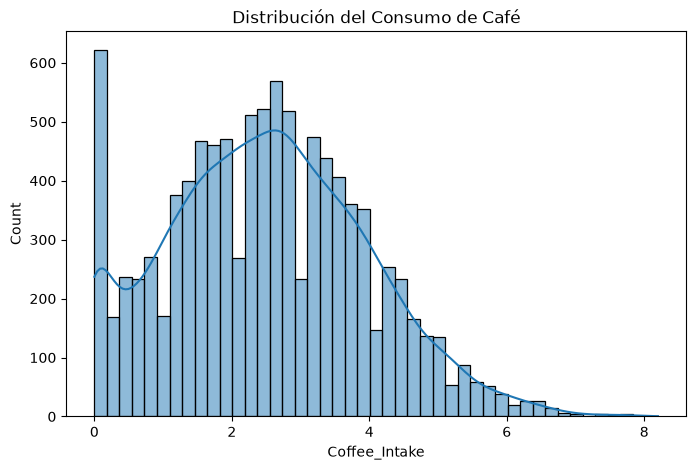

In [75]:
plt.figure(figsize=(8,5))
sns.histplot(df["Coffee_Intake"], kde=True)
plt.title("Distribución del Consumo de Café")
plt.show()

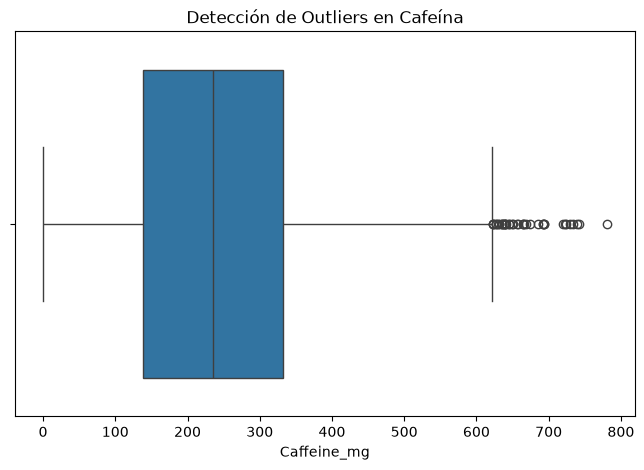

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Caffeine_mg"])
plt.title("Detección de Outliers en Cafeína")
plt.show()

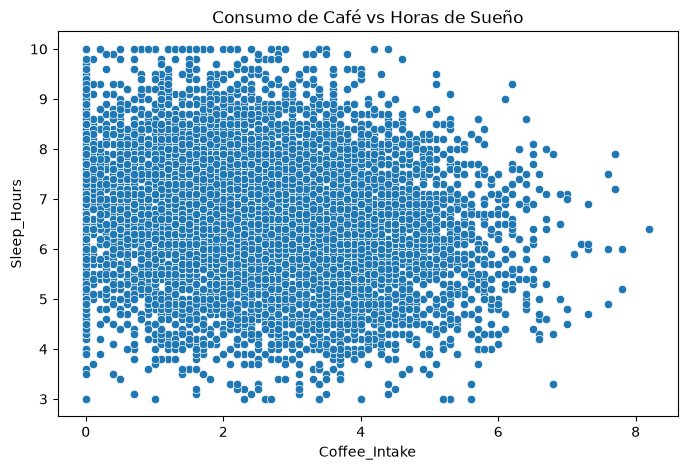

In [77]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Coffee_Intake",
    y="Sleep_Hours",
    data=df
)
plt.title("Consumo de Café vs Horas de Sueño")
plt.show()